In [1]:
import pandas as pd
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [2]:

df = pd.read_csv(r'C:\Project\EV station website\Processed datasets\Vehicle & Stations.csv')

In [3]:
df.isna().sum()

sr.no.                            0
State Name                        0
Two Wheeler                       0
Three Wheeler                     0
Four Wheeler                      0
Goods Vehicles                    0
Public Service Vehicle            0
Special Category Vehicles         0
Construction Equipment Vehicle    0
Other                             0
Grand Total                       0
Public Charging Stations          0
Total Population                  0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.describe()

,sr.no.,Two Wheeler,Three Wheeler,Four Wheeler,Goods Vehicles,Public Service Vehicle,Special Category Vehicles,Construction Equipment Vehicle,Other,Grand Total,Public Charging Stations,Total Population
count,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,3.600000e+01
mean,18.500000,69033.750000,16763.083333,8539.527778,530.833333,221.583333,18.222222,17.416667,164.527778,95288.944444,770.472222,3.364011e+07
std,10.535654,101756.337235,34130.613110,12413.325710,842.213224,500.383646,88.238350,64.194515,483.208295,128706.795213,864.028819,4.305190e+07
min,1.000000,3.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.000000,1.000000,6.447300e+04
25%,9.750000,580.500000,236.000000,140.750000,11.000000,4.500000,0.000000,0.000000,0.000000,1341.250000,57.250000,1.439840e+06
50%,18.500000,19592.500000,7786.000000,2323.500000,92.000000,26.000000,0.000000,0.000000,3.500000,43786.000000,476.500000,2.106970e+07
75%,27.250000,104309.750000,13855.250000,9103.500000,789.750000,151.000000,5.000000,2.250000,92.500000,133593.250000,1384.750000,5.229275e+07
max,36.000000,425917.000000,188160.000000,52145.000000,4013.000000,2707.000000,531.000000,366.000000,2442.000000,496417.000000,3284.000000,1.998123e+08


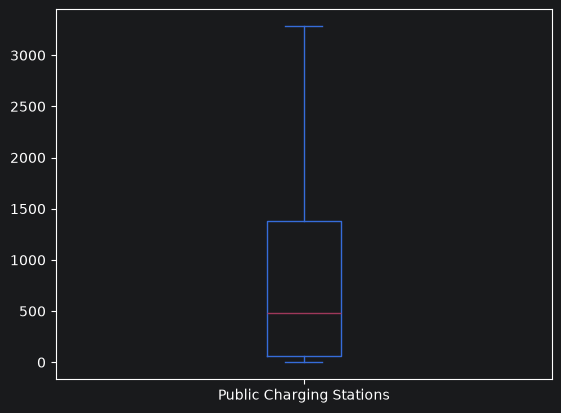

In [6]:
df['Public Charging Stations'].plot(kind='box')
plt.show()

In [7]:
df.head()

,sr.no.,State Name,Two Wheeler,Three Wheeler,Four Wheeler,Goods Vehicles,Public Service Vehicle,Special Category Vehicles,Construction Equipment Vehicle,Other,Grand Total,Public Charging Stations,Total Population
0,1,Andaman and Nicobar Island,116,30,69,1,2,0,0,0,218,8,380581
1,2,Andhra Pradesh,97784,6690,10275,448,73,0,19,146,115435,1384,49577103
2,3,Arunachal Pradesh,49,3,78,3,10,0,0,0,143,55,1383727
3,4,Assam,7477,67562,718,89,105,0,2,404,76357,526,31205576
4,5,Bihar,52293,71673,1976,250,27,0,0,179,126398,762,104099452


In [8]:
df.dtypes

sr.no.                            int64
State Name                          str
Two Wheeler                       int64
Three Wheeler                     int64
Four Wheeler                      int64
Goods Vehicles                    int64
Public Service Vehicle            int64
Special Category Vehicles         int64
Construction Equipment Vehicle    int64
Other                             int64
Grand Total                       int64
Public Charging Stations          int64
Total Population                  int64
dtype: object

In [9]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

encoded = encoder.fit_transform(df[['State Name']])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['State Name']),
    index=df.index
)

df = pd.concat(
    [df.drop('State Name', axis=1), encoded_df],
    axis=1
)

In [10]:
df.drop(columns=['sr.no.'], inplace=True)

In [11]:
df.head()

,Two Wheeler,Three Wheeler,Four Wheeler,Goods Vehicles,Public Service Vehicle,Special Category Vehicles,Construction Equipment Vehicle,Other,Grand Total,Public Charging Stations,...,State Name_Puducherry,State Name_Punjab,State Name_Rajasthan,State Name_Sikkim,State Name_Tamil Nadu,State Name_Telangana,State Name_Tripura,State Name_Uttar Pradesh,State Name_Uttarakhand,State Name_West Bengal
0,116,30,69,1,2,0,0,0,218,8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,97784,6690,10275,448,73,0,19,146,115435,1384,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,49,3,78,3,10,0,0,0,143,55,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,7477,67562,718,89,105,0,2,404,76357,526,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,52293,71673,1976,250,27,0,0,179,126398,762,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
print(df.columns)
print(df.shape)

Index(['Two Wheeler', 'Three Wheeler', 'Four Wheeler', 'Goods Vehicles',
       'Public Service Vehicle', 'Special Category Vehicles',
       'Construction Equipment Vehicle', 'Other', 'Grand Total',
       'Public Charging Stations', 'Total Population',
       'State Name_Andaman and Nicobar Island', 'State Name_Andhra Pradesh',
       'State Name_Arunachal Pradesh', 'State Name_Assam', 'State Name_Bihar',
       'State Name_Chandigarh', 'State Name_Chhattisgarh',
       'State Name_Dadra and Nagar Haveli and Daman and Diu',
       'State Name_Delhi', 'State Name_Goa', 'State Name_Gujarat',
       'State Name_Haryana', 'State Name_Himachal Pradesh',
       'State Name_Jammu and Kashmir', 'State Name_Jharkhand',
       'State Name_Karnataka', 'State Name_Kerala', 'State Name_Ladakh',
       'State Name_Lakshdweep', 'State Name_Madhya Pradesh',
       'State Name_Maharashtra', 'State Name_Manipur', 'State Name_Meghalaya',
       'State Name_Mizoram', 'State Name_Nagaland', 'State Name_O

In [13]:
X = df.drop(columns='Public Charging Stations')
y = df['Public Charging Stations']

## Train Test Split

### Linear Model

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [15]:
lr_pipe = make_pipeline(StandardScaler(), LinearRegression())

In [16]:
lr_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](46,)","['Two Wheeler','Three Wheeler','Four Wheeler',..., 'State Name_Uttar Pradesh','State Name_Uttarakhand', 'State Name_West Bengal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,46
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [17]:
lr_test_pred = lr_pipe.predict(X_test)
lr_train_pred = lr_pipe.predict(X_train)

In [18]:
def metrics(y_train, y_test, y_train_pred, y_test_pred):
    print("MSE of model:", mean_squared_error(y_test, y_test_pred))
    print("MAE of model:", mean_absolute_error(y_test, y_test_pred))


    print("Training R2 Score:",round(r2_score(y_train, y_train_pred)*100,4),"%")
    print("Testing R2 Score:", round(r2_score(y_test, y_test_pred)*100,4),"%")

In [19]:
metrics(y_train, y_test,lr_train_pred,lr_test_pred )

MSE of model: 161481.19231293965
MAE of model: 308.5078448133812
Training R2 Score: 100.0 %
Testing R2 Score: 50.4383 %


### Decision Tree Regressor

In [20]:
dtr = DecisionTreeRegressor()

In [21]:
dtr.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree wi

In [22]:
dtr_ytest_pred = dtr.predict(X_test)

In [23]:
dtr_ytrain_pred = dtr.predict(X_train)

In [24]:
metrics(y_train, y_test, dtr_ytrain_pred,dtr_ytest_pred )

MSE of model: 159023.5
MAE of model: 246.25
Training R2 Score: 100.0 %
Testing R2 Score: 51.1926 %


### RandomForestRegressor

In [25]:
rfr = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

In [26]:
rfr.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [27]:
rfr_ytest_pred = rfr.predict(X_test)
rfr_ytrain_pred = rfr.predict(X_train)

In [28]:
metrics(y_train, y_test,rfr_ytrain_pred,rfr_ytest_pred )

MSE of model: 75427.187853
MAE of model: 185.9355
Training R2 Score: 97.1791 %
Testing R2 Score: 76.8499 %


### XGBoost

In [29]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

In [30]:
xgb.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [31]:
xgb_ytest_pred = xgb.predict(X_test)
xgb_ytrain_pred = xgb.predict(X_train)

In [32]:
metrics(y_train, y_test,xgb_ytrain_pred,xgb_ytest_pred )

MSE of model: 162026.140625
MAE of model: 278.2630310058594
Training R2 Score: 100.0 %
Testing R2 Score: 50.2711 %


## KFold

In [33]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

In [34]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Linear Regression": lr_pipe,
    "Decision Tree": dtr,
    "Random Forest": rfr,
    "XGBoost": xgb
}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=kfold,
        scoring='r2'
    )

    print(f"\n{name}")
    print("Fold R² Scores:", scores)
    print("Mean R²:", round(scores.mean() * 100, 2), "%")
    print("Std:", round(scores.std() * 100, 2), "%")


Linear Regression
Fold R² Scores: [-0.38877414  0.62365554 -0.15817916  0.73367896  0.66517655]
Mean R²: 29.51 %
Std: 47.13 %

Decision Tree
Fold R² Scores: [0.30361186 0.66498641 0.20197559 0.81560319 0.7229017 ]
Mean R²: 54.18 %
Std: 24.3 %

Random Forest
Fold R² Scores: [0.67664006 0.89872307 0.8212052  0.91063148 0.54330072]
Mean R²: 77.01 %
Std: 14.08 %

XGBoost
Fold R² Scores: [ 0.76847589  0.87082386 -0.00192487  0.93882436  0.45977896]
Mean R²: 60.72 %
Std: 34.59 %


### Tuned Random Forest

In [39]:
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 8, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 'log2', 0.5, 1.0]
}

rf = RandomForestRegressor(
    random_state=42
)

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best parameters:")
print(rf_search.best_params_)

print("\nBest CV R2:")
print(rf_search.best_score_)

Best parameters:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 20}

Best CV R2:
0.8241642700317302


In [40]:
best_rf = rf_search.best_estimator_

In [41]:
best_rf_pred = best_rf.predict(X_test)

print("Test MAE:",
      mean_absolute_error(y_test, best_rf_pred))

print("Test MSE:",
      mean_squared_error(y_test, best_rf_pred))

print("Test R2:",
      r2_score(y_test, best_rf_pred))

Test MAE: 182.10530898268408
Test MSE: 71164.01428523139
Test R2: 0.7815839481307055


In [42]:
print(rf_search.best_params_)

{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 20}


In [43]:
importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

Goods Vehicles                                         2.057745e-01
Total Population                                       2.051554e-01
Two Wheeler                                            1.995642e-01
Grand Total                                            1.680786e-01
Four Wheeler                                           8.800835e-02
Other                                                  6.388276e-02
Three Wheeler                                          2.027764e-02
Public Service Vehicle                                 1.891022e-02
Construction Equipment Vehicle                         1.393859e-02
State Name_Uttar Pradesh                               8.210384e-03
Special Category Vehicles                              3.237468e-03
State Name_Andhra Pradesh                              9.984982e-04
State Name_Odisha                                      7.805600e-04
State Name_Madhya Pradesh                              7.437820e-04
State Name_Haryana                              

In [44]:
cv_scores_tuned = cross_val_score(
    best_rf,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Tuned RF CV scores:", cv_scores_tuned)
print("Mean Tuned RF CV R2:", cv_scores_tuned.mean())

Tuned RF CV scores: [0.94069213 0.96602317 0.68851731 0.76455728 0.76103147]
Mean Tuned RF CV R2: 0.8241642700317302


### Tuned Decision Tree

In [45]:
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8, 10],
    'max_features': [None, 'sqrt', 'log2']
}

dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_search = RandomizedSearchCV(
    estimator=dt_model,
    param_distributions=param_grid_dt,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

dt_search.fit(X_train, y_train)

print("Best Parameters:", dt_search.best_params_)
print("Best CV R²:", dt_search.best_score_)

Best Parameters: {'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': None, 'max_depth': 7}
Best CV R²: 0.5800900673851662


In [47]:
best_dt = dt_search.best_estimator_

In [51]:
best_dt_pred = best_dt.predict(X_test)

print("Decision Tree Test MAE:",
      mean_absolute_error(y_test, best_dt_pred))

print("Decision Tree Test MSE:",
      mean_squared_error(y_test, best_dt_pred))

print("Decision Tree Test R2:",
      r2_score(y_test, best_dt_pred))

Decision Tree Test MAE: 286.3958333333333
Decision Tree Test MSE: 169216.17393663194
Decision Tree Test R2: 0.48064300482642763


### Tunned XGB

In [49]:
param_grid_xgb = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.3, 0.5]
}

xgb_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid_xgb,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

print("Best Parameters:", xgb_search.best_params_)
print("Best CV R²:", xgb_search.best_score_)

Best Parameters: {'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 3, 'learning_rate': 0.03, 'gamma': 0.3, 'colsample_bytree': 0.8}
Best CV R²: 0.8111032247543335


In [50]:
best_xgb = xgb_search.best_estimator_

In [52]:
best_xgb_pred = best_xgb.predict(X_test)

print("XGBoost Test MAE:",
      mean_absolute_error(y_test, best_xgb_pred))

print("XGBoost Test MSE:",
      mean_squared_error(y_test, best_xgb_pred))

print("XGBoost Test R2:",
      r2_score(y_test, best_xgb_pred))

XGBoost Test MAE: 207.93035888671875
XGBoost Test MSE: 127436.6640625
XGBoost Test R2: 0.6088723540306091


In [54]:
# Predictions
rf_pred = best_rf.predict(X_test)
dt_pred = best_dt.predict(X_test)
xgb_pred = best_xgb.predict(X_test)


# Random Forest
print("===== Random Forest =====")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", mean_squared_error(y_test, rf_pred) ** 0.5)
print("R2:", r2_score(y_test, rf_pred))

# XGBoost
print("\n===== XGBoost =====")
print("MAE:", mean_absolute_error(y_test, xgb_pred))
print("RMSE:", mean_squared_error(y_test, xgb_pred) ** 0.5)
print("R2:", r2_score(y_test, xgb_pred))

===== Random Forest =====
MAE: 182.10530898268408
RMSE: 266.76584167623747
R2: 0.7815839481307055

===== XGBoost =====
MAE: 207.93035888671875
RMSE: 356.98272235851977
R2: 0.6088723540306091


In [55]:
print("Target Minimum:", y.min())
print("Target Maximum:", y.max())
print("Target Mean:", y.mean())
print("Target Median:", y.median())

Target Minimum: 1
Target Maximum: 3284
Target Mean: 770.4722222222222
Target Median: 476.5


In [58]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

In [59]:
print(feature_importance.head(15))

                           Feature  Importance
3                   Goods Vehicles    0.205775
9                 Total Population    0.205155
0                      Two Wheeler    0.199564
8                      Grand Total    0.168079
2                     Four Wheeler    0.088008
7                            Other    0.063883
1                    Three Wheeler    0.020278
4           Public Service Vehicle    0.018910
6   Construction Equipment Vehicle    0.013939
43        State Name_Uttar Pradesh    0.008210
5        Special Category Vehicles    0.003237
11       State Name_Andhra Pradesh    0.000998
35               State Name_Odisha    0.000781
29       State Name_Madhya Pradesh    0.000744
21              State Name_Haryana    0.000612


In [60]:
import pickle

In [62]:
fh = open(r'C:\Project\EV station website\pickle files\ChargingStationRequirement.pkl', 'wb')
pickle.dump(best_rf, fh)
fh.close()